<a href="https://colab.research.google.com/github/BrooksInGit/AI-ML-Coursework/blob/main/EasyVisa_Full_Code_Notebook_James_Brooks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Problem Statement

### Business Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

### Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data  scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

### Data Description

The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

## Installing and Importing the necessary libraries

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 scikit-learn==1.5.2 matplotlib==3.7.1 seaborn==0.13.1 xgboost==2.0.3 -q --user

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the below.*

In [ ]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Library to split data
from sklearn.model_selection import train_test_split

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score


# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

# Libraries to get different metric scores
from sklearn import metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# To tune different models
from sklearn.model_selection import RandomizedSearchCV

# To ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Import Dataset

In [ ]:
df = pd.read_csv('/content/sample_data/EasyVisa.csv')

## Overview of the Dataset

#### View the first and last 5 rows of the dataset

In [ ]:
df.head(5)

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


#### Understand the shape of the dataset

In [ ]:
df.shape

(25480, 12)

#### Check the data types of the columns for the dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


## Exploratory Data Analysis (EDA)

#### Let's check the statistical summary of the data

In [ ]:
df.describe()

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000000,25480.000000,25480.000000
mean,5667.043210,1979.409929,74455.814592
std,22877.928848,42.366929,52815.942327
min,-26.000000,1800.000000,2.136700
25%,1022.000000,1976.000000,34015.480000
50%,2109.000000,1997.000000,70308.210000
75%,3504.000000,2005.000000,107735.512500
max,602069.000000,2016.000000,319210.270000


#### Fixing the negative values in number of employees columns

In [ ]:
df['no_of_employees'] = df['no_of_employees'].abs()

#### Let's check the count of each unique category in each of the categorical variables

In [ ]:
# Selecting only categorical features
categorical_features = df.select_dtypes(include=['object']).columns

# Print the count of each unique category in each categorical feature
for col in categorical_features:
  print(f"Value counts for column: {col}")
  print(df[col].value_counts())
  print("-" * 30)


Value counts for column: case_id
EZYV01       1
EZYV16995    1
EZYV16993    1
EZYV16992    1
EZYV16991    1
            ..
EZYV8492     1
EZYV8491     1
EZYV8490     1
EZYV8489     1
EZYV25480    1
Name: case_id, Length: 25480, dtype: int64
------------------------------
Value counts for column: continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: continent, dtype: int64
------------------------------
Value counts for column: education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: education_of_employee, dtype: int64
------------------------------
Value counts for column: has_job_experience
Y    14802
N    10678
Name: has_job_experience, dtype: int64
------------------------------
Value counts for column: requires_job_training
N    22525
Y     2955
Name: requires_job_training, dtype: int64
------------------------------
Value counts

### Univariate Analysis

In [ ]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

    plt.show()

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

#### Observations on education of employee

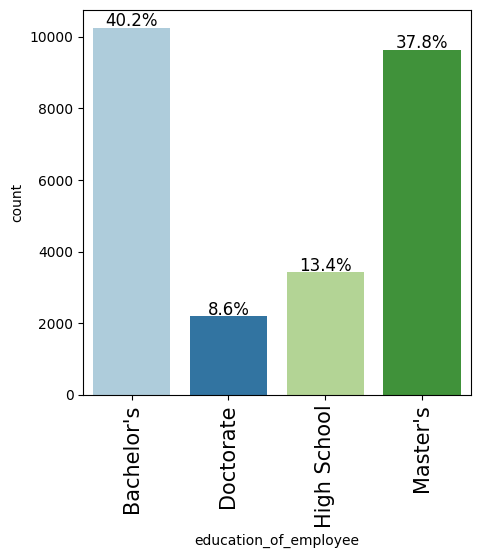

In [ ]:
labeled_barplot(df, 'education_of_employee', perc=True)


#### Observations on region of employment

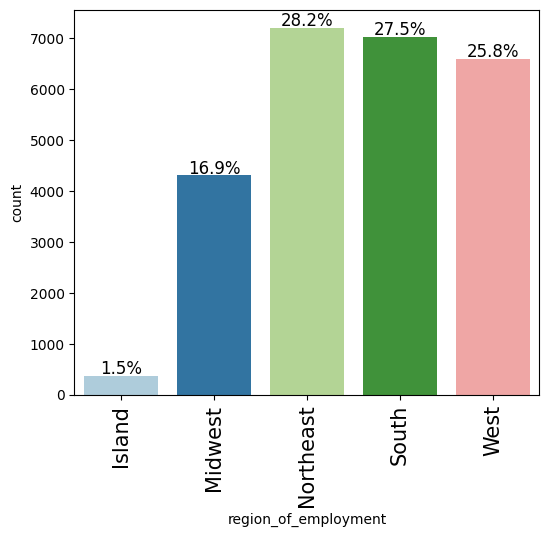

In [ ]:
labeled_barplot(df, 'region_of_employment', perc=True)

#### Observations on job experience

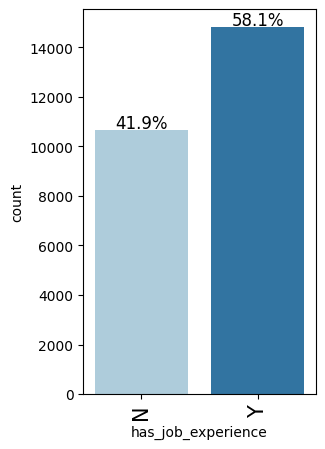

In [ ]:
labeled_barplot(df, "has_job_experience", perc=True)

#### Observations on case status

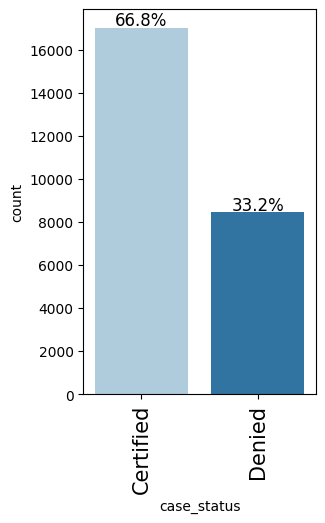

In [ ]:
labeled_barplot(df, 'case_status', perc=True)

### Bivariate Analysis

**Creating functions that will help us with further analysis.**

In [ ]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

In [ ]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

Does higher education increase the chances of visa certification for well-paid jobs abroad?

case_status            Certified  Denied    All
education_of_employee                          
All                        17018    8462  25480
Bachelor's                  6367    3867  10234
High School                 1164    2256   3420
Master's                    7575    2059   9634
Doctorate                   1912     280   2192
------------------------------------------------------------------------------------------------------------------------


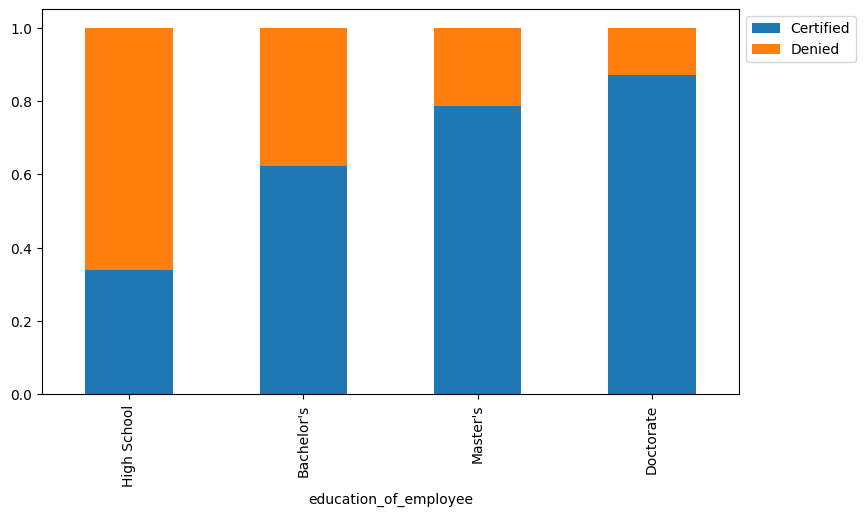

In [ ]:
stacked_barplot(df, 'education_of_employee', 'case_status')


#### How does visa status vary across different continents?

case_status    Certified  Denied    All
continent                              
All                17018    8462  25480
Asia               11012    5849  16861
North America       2037    1255   3292
Europe              2957     775   3732
South America        493     359    852
Africa               397     154    551
Oceania              122      70    192
------------------------------------------------------------------------------------------------------------------------


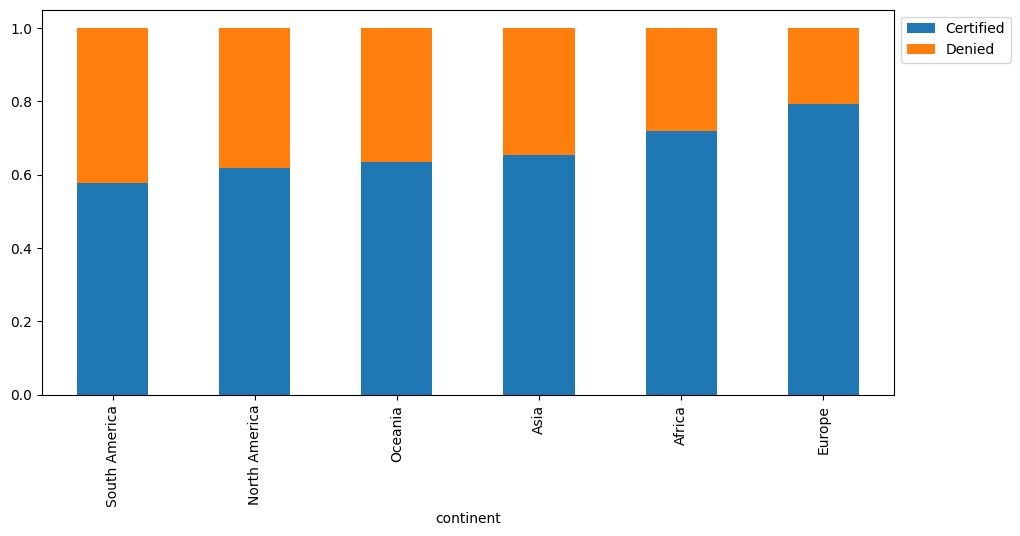

In [ ]:
stacked_barplot(df,'continent', 'case_status' )

#### Does having prior work experience influence the chances of visa certification for career opportunities abroad?

case_status         Certified  Denied    All
has_job_experience                          
All                     17018    8462  25480
N                        5994    4684  10678
Y                       11024    3778  14802
------------------------------------------------------------------------------------------------------------------------


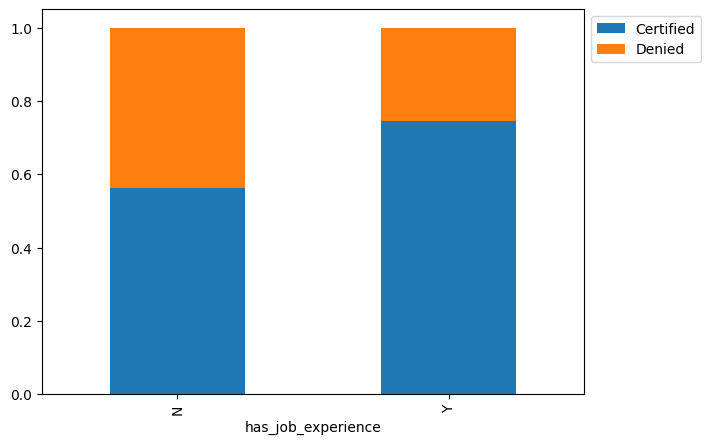

In [ ]:
stacked_barplot(df,'has_job_experience', 'case_status' )

#### Is the prevailing wage consistent across all regions of the US?

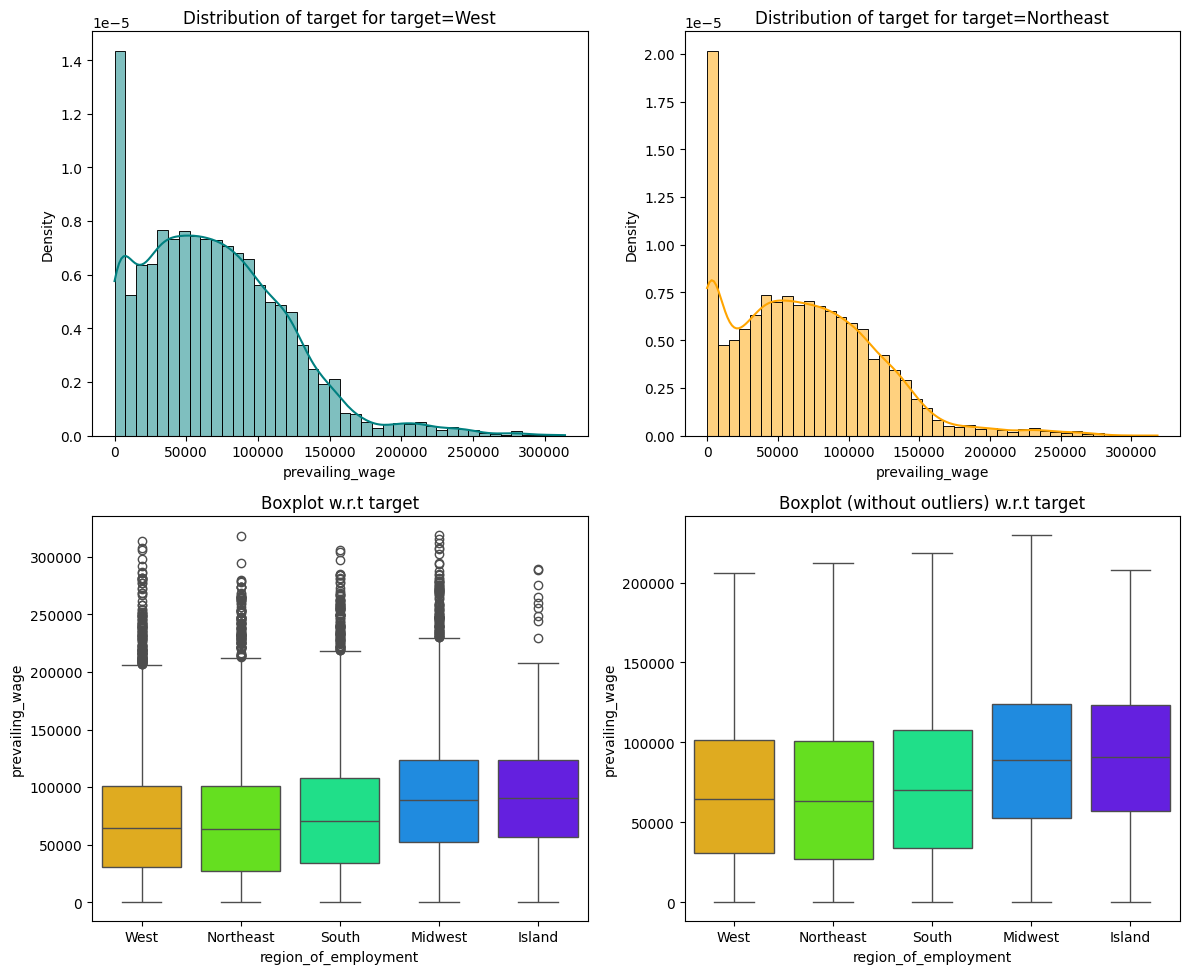

In [ ]:

distribution_plot_wrt_target(df, 'prevailing_wage', 'region_of_employment')


#### Does visa status vary with changes in the prevailing wage set to protect both local talent and foreign workers?

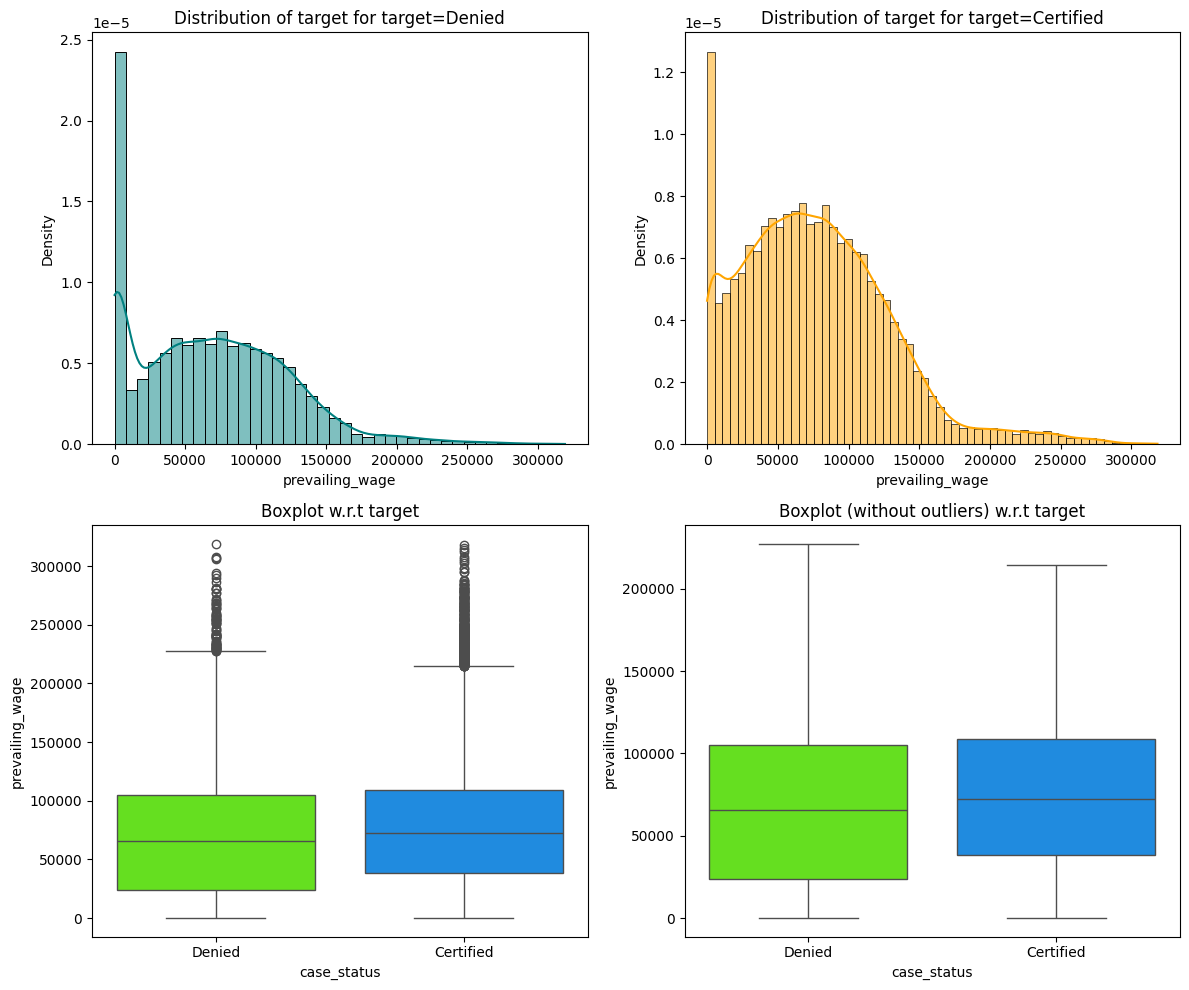

In [ ]:
distribution_plot_wrt_target(df, 'prevailing_wage', 'case_status')


#### Does the unit of prevailing wage (Hourly, Weekly, etc.) have any impact on the likelihood of visa application certification?

case_status   Certified  Denied    All
unit_of_wage                          
All               17018    8462  25480
Year              16047    6915  22962
Hour                747    1410   2157
Week                169     103    272
Month                55      34     89
------------------------------------------------------------------------------------------------------------------------


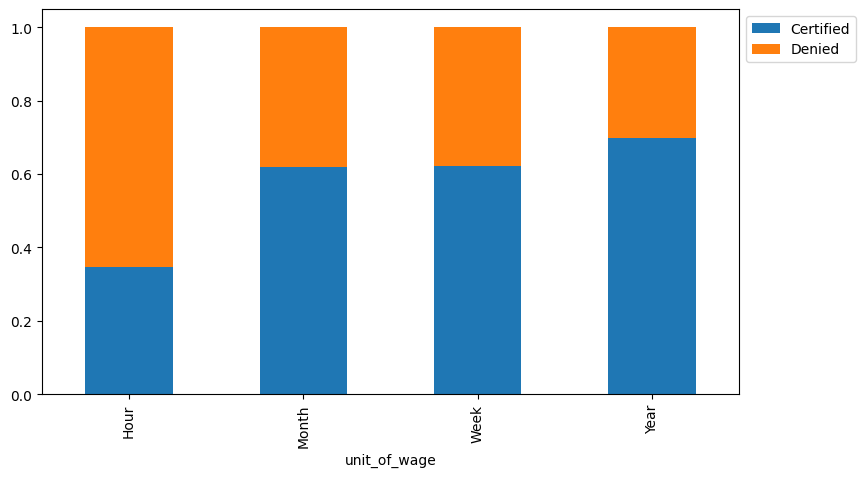

In [ ]:
stacked_barplot(df, 'unit_of_wage', 'case_status')

## Data Pre-processing

### Outlier Check

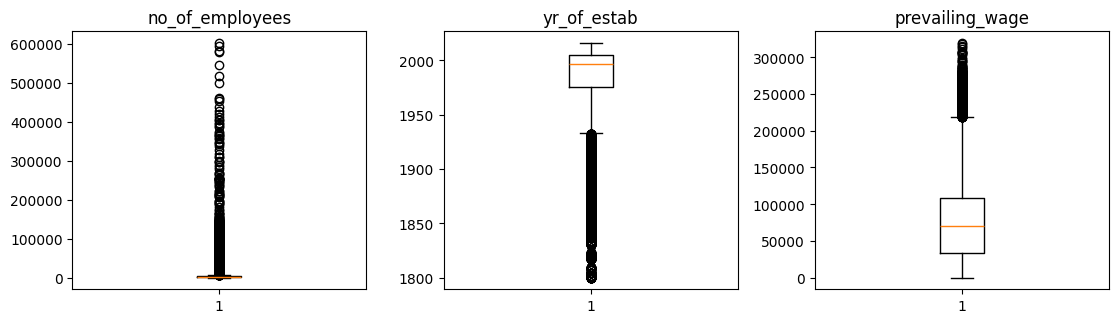

In [ ]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()


plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(df[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

### Data Preparation for modeling

In [ ]:

# --- GLOBAL RESULTS TRACKER ---
all_model_results = []

# --- Step 0: Create a copy of the DataFrame ---
data = df.copy()
print("DataFrame 'df' copied to 'data' for processing.")

# --- Step 1: Encode the target variable 'case_status' ---
data["case_status"] = data["case_status"].apply(lambda x: 1 if x == "Certified" else 0)
print("\n'case_status' column encoded to numerical (1 for Certified, 0 for Denied).")

# --- Step 2: Separate features (X) and target (y) ---
# Drop 'case_status' (the target) and 'case_id' (an identifier) from features
X = data.drop(['case_status', 'case_id'], axis=1)
y = data["case_status"]
print("Features (X) and target (y) separated.")

# --- Step 3: One-Hot Encode categorical features in X ---
# pd.get_dummies will automatically identify object/category columns and convert them.
X = pd.get_dummies(X, drop_first=True)
print("Categorical features in X one-hot encoded using pd.get_dummies.")

# --- Step 4: Split the dataset into train, validation, and test sets ---

# First split: 70% for training, 30% for (validation + test)
X_train, X_val_temp, y_train, y_val_temp = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y
)
print("\nFirst split (Train/Val+Test) completed.")

# Second split: From the 30% (validation + test) part, split into 90% validation and 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_val_temp, y_val_temp, test_size=0.1, random_state=1, stratify=y_val_temp
)
print("Second split (Validation/Test) completed.")

# --- Step 5: Print shapes and class percentages ---
print("\n--- Dataset Splits Summary ---")
print("Shape of Training set   : ", X_train.shape)
print("Shape of Validation set : ", X_val.shape)
print("Shape of Test set       : ", X_test.shape)

print("\nPercentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in validation set:")
print(y_val.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

DataFrame 'df' copied to 'data' for processing.

'case_status' column encoded to numerical (1 for Certified, 0 for Denied).
Features (X) and target (y) separated.
Categorical features in X one-hot encoded using pd.get_dummies.

First split (Train/Val+Test) completed.
Second split (Validation/Test) completed.

--- Dataset Splits Summary ---
Shape of Training set   :  (17836, 21)
Shape of Validation set :  (6879, 21)
Shape of Test set       :  (765, 21)

Percentage of classes in training set:
case_status
1    0.667919
0    0.332081
Name: proportion, dtype: float64
Percentage of classes in validation set:
case_status
1    0.66783
0    0.33217
Name: proportion, dtype: float64
Percentage of classes in test set:
case_status
1    0.667974
0    0.332026
Name: proportion, dtype: float64


## Model Building

### Model Evaluation Criterion

- Choose the primary metric to evaluate the model on
- Elaborate on the rationale behind choosing the metric

First, let's create functions to calculate different metrics and confusion matrix so that we don't have to use the same code repeatedly for each model.
* The `model_performance_classification_sklearn` function will be used to check the model performance of models.
* The `confusion_matrix_sklearn` function will be used to plot the confusion matrix.

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn


def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [ ]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

#### Defining scorer to be used for cross-validation and hyperparameter tuning

**We are now done with pre-processing and evaluation criterion, so let's start building the model.**

### Model building with Original data

In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list (including the ones you specified)
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random Forest", RandomForestClassifier(random_state=1))) # This is the one we focused on last
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss", use_label_encoder=False)))


results_cv = []  # Empty list to store all model's CV scores
results_val = [] # Empty list to store all model's validation scores
names = []  # Empty list to store name of the models

# Define the scorer for F1-score
scorer = 'f1'

print("\n" "--- Cross-Validation performance on training dataset (F1-score):" "\n")

for name, model in models:
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )
    cv_result = cross_val_score(
        estimator=model, X=X_train, y=y_train, scoring=scorer, cv=kfold
    )
    results_cv.append(cv_result)
    names.append(name)
    print("{}: {:.4f} (Std: {:.4f})".format(name, cv_result.mean(), cv_result.std())) # Added std for robustness

print("\n" "--- Validation Performance (F1-score):" "\n")

for name, model in models:
    model.fit(X_train, y_train) # Fit the model on the full training data

    # Use F1-score as our primary metric for validation set evaluation
    val_f1_score = f1_score(y_val, model.predict(X_val))
    results_val.append(val_f1_score) # Store validation F1 score
    print("{}: {:.4f}".format(name, val_f1_score))

print("\nAll specified models have been trained and evaluated for comparison.")


--- Cross-Validation performance on training dataset (F1-score):

Bagging: 0.7757 (Std: 0.0024)
Random Forest: 0.8038 (Std: 0.0019)
GBM: 0.8230 (Std: 0.0027)
Adaboost: 0.8203 (Std: 0.0036)
Xgboost: 0.8074 (Std: 0.0033)
Decision Tree: 0.7411 (Std: 0.0035)

--- Validation Performance (F1-score):

Bagging: 0.7676
Random Forest: 0.7972
GBM: 0.8196
Adaboost: 0.8158
Xgboost: 0.8070
Decision Tree: 0.7477

All specified models have been trained and evaluated for comparison.


### Model Building with Oversampled data

In [ ]:
# --- Apply SMOTE to Training Data ---
print("\n--- Applying SMOTE to Training Data ---")
sm = SMOTE(random_state=1)
X_train_oversampled, y_train_oversampled = sm.fit_resample(X_train, y_train)

print(f"Original training set shape: {X_train.shape}, {y_train.shape}")
print(f"Oversampled training set shape: {X_train_oversampled.shape}, {y_train_oversampled.shape}")
print(f"Class distribution after SMOTE:\n{y_train_oversampled.value_counts(normalize=True)}")

# --- Model Building: Compare All Models with Oversampled Data ---

models_oversampled = []
models_oversampled.append(("Bagging", BaggingClassifier(random_state=1)))
models_oversampled.append(("Random Forest", RandomForestClassifier(random_state=1)))
models_oversampled.append(("GBM", GradientBoostingClassifier(random_state=1)))
models_oversampled.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models_oversampled.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss", use_label_encoder=False)))
models_oversampled.append(("Decision Tree", DecisionTreeClassifier(random_state=1)))

oversampled_val_f1_scores = {} # Dictionary to store validation F1 scores

print("\n" "--- Evaluating Models on Oversampled Training Data (F1-score on Validation Set):" "\n")

for name, model in models_oversampled:
    print(f"Training {name} on oversampled data...")
    model.fit(X_train_oversampled, y_train_oversampled) # Fit on oversampled training data
    val_f1_score = f1_score(y_val, model.predict(X_val)) # Evaluate on original validation set
    oversampled_val_f1_scores[name] = val_f1_score
    print(f"{name}: {val_f1_score:.4f}")

print("\nEvaluation of all models with oversampled data complete.")


--- Applying SMOTE to Training Data ---
Original training set shape: (17836, 21), (17836,)
Oversampled training set shape: (23826, 21), (23826,)
Class distribution after SMOTE:
case_status
1    0.5
0    0.5
Name: proportion, dtype: float64

--- Evaluating Models on Oversampled Training Data (F1-score on Validation Set):

Training Bagging on oversampled data...
Bagging: 0.7607
Training Random Forest on oversampled data...
Random Forest: 0.7954
Training GBM on oversampled data...
GBM: 0.8125
Training Adaboost on oversampled data...
Adaboost: 0.8120
Training Xgboost on oversampled data...
Xgboost: 0.8040
Training Decision Tree on oversampled data...
Decision Tree: 0.7388

Evaluation of all models with oversampled data complete.


### Model Building with Undersampled data

In [ ]:
# --- Apply RandomUnderSampler to Training Data ---
print("\n--- Applying RandomUnderSampler to Training Data ---")
rus = RandomUnderSampler(random_state=1)
X_train_undersampled, y_train_undersampled = rus.fit_resample(X_train, y_train)

print(f"Original training set shape: {X_train.shape}, {y_train.shape}")
print(f"Undersampled training set shape: {X_train_undersampled.shape}, {y_train_undersampled.shape}")
print(f"Class distribution after RandomUnderSampler:\n{y_train_undersampled.value_counts(normalize=True)}")

# --- Model Building: Compare All Models with Undersampled Data ---

models_undersampled = []
models_undersampled.append(("Bagging", BaggingClassifier(random_state=1)))
models_undersampled.append(("Random Forest", RandomForestClassifier(random_state=1)))
models_undersampled.append(("GBM", GradientBoostingClassifier(random_state=1)))
models_undersampled.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models_undersampled.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss", use_label_encoder=False)))
models_undersampled.append(("Decision Tree", DecisionTreeClassifier(random_state=1)))

undersampled_val_f1_scores = {} # Dictionary to store validation F1 scores

print("\n" "--- Evaluating Models on Undersampled Training Data (F1-score on Validation Set):" "\n")

for name, model in models_undersampled:
    print(f"Training {name} on undersampled data...")
    model.fit(X_train_undersampled, y_train_undersampled) # Fit on undersampled training data
    val_f1_score = f1_score(y_val, model.predict(X_val)) # Evaluate on original validation set
    undersampled_val_f1_scores[name] = val_f1_score
    print(f"{name}: {val_f1_score:.4f}")

print("\nEvaluation of all models with undersampled data complete.")


--- Applying RandomUnderSampler to Training Data ---
Original training set shape: (17836, 21), (17836,)
Undersampled training set shape: (11846, 21), (11846,)
Class distribution after RandomUnderSampler:
case_status
0    0.5
1    0.5
Name: proportion, dtype: float64

--- Evaluating Models on Undersampled Training Data (F1-score on Validation Set):

Training Bagging on undersampled data...
Bagging: 0.6917
Training Random Forest on undersampled data...
Random Forest: 0.7341
Training GBM on undersampled data...
GBM: 0.7609
Training Adaboost on undersampled data...
Adaboost: 0.7604
Training Xgboost on undersampled data...
Xgboost: 0.7424
Training Decision Tree on undersampled data...
Decision Tree: 0.6839

Evaluation of all models with undersampled data complete.


## Hyperparameter Tuning

**Best practices for hyperparameter tuning in AdaBoost:**

`n_estimators`:

- Start with a specific number (50 is used in general) and increase in steps: 50, 75, 85, 100

- Use fewer estimators (e.g., 50 to 100) if using complex base learners (like deeper decision trees)

- Use more estimators (e.g., 100 to 150) when learning rate is low (e.g., 0.1 or lower)

- Avoid very high values unless performance keeps improving on validation

`learning_rate`:

- Common values to try: 1.0, 0.5, 0.1, 0.01

- Use 1.0 for faster training, suitable for fewer estimators

- Use 0.1 or 0.01 when using more estimators to improve generalization

- Avoid very small values (< 0.01) unless you plan to use many estimators (e.g., >500) and have sufficient data


---


--- Hyperparameter Tuning for AdaBoostClassifier using RandomizedSearchCV ---

Fitting RandomizedSearchCV on oversampled training data...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters for AdaBoost (on oversampled data): {'n_estimators': np.int64(100), 'learning_rate': 0.5, 'estimator': DecisionTreeClassifier(max_depth=3, random_state=1)}
Best F1-score (CV on oversampled training data): 0.8037559763906834

--- Model Performance on Validation Set (Tuned AdaBoost on Oversampled Data) ---
   Accuracy    Recall  Precision        F1
0  0.734264  0.839356    0.77962  0.808386

Confusion Matrix for Validation Set (Tuned AdaBoost on Oversampled Data):

AdaBoost hyperparameter tuning with RandomizedSearchCV on oversampled data complete.


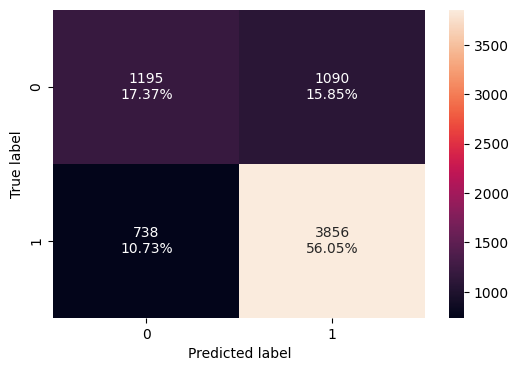

In [ ]:
import numpy as np
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

scorer = 'f1'

print("\n--- Hyperparameter Tuning for AdaBoostClassifier using RandomizedSearchCV ---")

# defining model
model = AdaBoostClassifier(random_state=1)

# Parameter grid to pass in RandomizedSearchCV
param_grid = {
    "n_estimators": np.arange(50, 201, 25), # From 50 to 200, in steps of 25 (e.g., 50, 75, 100, 125, 150, 175, 200)
    "learning_rate": [0.01, 0.05, 0.1, 0.2, 0.5, 1.0], # Common values and some in between
    "estimator": [ # Corrected parameter name from base_estimator to estimator for scikit-learn >= 1.2
        DecisionTreeClassifier(max_depth=1, random_state=1),
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ]
}

#Calling RandomizedSearchCV
randomized_cv_adaboost = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=50, # Number of parameter settings that are sampled
    n_jobs=-2, # Use all available cores except one, -1 would use all
    scoring=scorer,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=1),
    random_state=1,
    verbose=1 # To see progress
)

#Fitting parameters in RandomizedSearchCV
print("\nFitting RandomizedSearchCV on oversampled training data...")
randomized_cv_adaboost.fit(X_train_oversampled, y_train_oversampled)

# Get the best model
best_adaboost_model_oversampled = randomized_cv_adaboost.best_estimator_

print("\nBest parameters for AdaBoost (on oversampled data):", randomized_cv_adaboost.best_params_)
print("Best F1-score (CV on oversampled training data):", randomized_cv_adaboost.best_score_)

# --- Evaluate the Best AdaBoost Model on the Original Validation Set ---

print("\n--- Model Performance on Validation Set (Tuned AdaBoost on Oversampled Data) ---")
adaboost_oversampled_val_perf = model_performance_classification_sklearn(best_adaboost_model_oversampled, X_val, y_val)
print(adaboost_oversampled_val_perf)

# --- STORE RESULTS FOR TUNED ADABOOST ---
all_model_results.append({
    "Model": "Adaboost",
    "Sampling Strategy": "Oversampled", # This reflects how it was actually tuned
    "Tuning Status": "Tuned",
    "F1-score (Val)": adaboost_oversampled_val_perf['F1'].iloc[0],
    "Accuracy (Val)": adaboost_oversampled_val_perf['Accuracy'].iloc[0],
    "Recall (Val)": adaboost_oversampled_val_perf['Recall'].iloc[0],
    "Precision (Val)": adaboost_oversampled_val_perf['Precision'].iloc[0],
    "Best Params": randomized_cv_adaboost.best_params_,
    "Best CV F1 (Train)": randomized_cv_adaboost.best_score_
})
# --- END STORE RESULTS ---

print("\nConfusion Matrix for Validation Set (Tuned AdaBoost on Oversampled Data):")
confusion_matrix_sklearn(best_adaboost_model_oversampled, X_val, y_val)

print("\nAdaBoost hyperparameter tuning with RandomizedSearchCV on oversampled data complete.")


**Best practices for hyperparameter tuning in Random Forest:**


`n_estimators`:

* Start with a specific number (50 is used in general) and increase in steps: 50, 75, 100, 125
* Higher values generally improve performance but increase training time
* Use 100-150 for large datasets or when variance is high


`min_samples_leaf`:

* Try values like: 1, 2, 4, 5, 10
* Higher values reduce model complexity and help prevent overfitting
* Use 1–2 for low-bias models, higher (like 5 or 10) for more regularized models
* Works well in noisy datasets to smooth predictions


`max_features`:

* Try values: `"sqrt"` (default for classification), `"log2"`, `None`, or float values (e.g., `0.3`, `0.5`)
* `"sqrt"` balances between diversity and performance for classification tasks
* Lower values (e.g., `0.3`) increase tree diversity, reducing overfitting
* Higher values (closer to `1.0`) may capture more interactions but risk overfitting


`max_samples` (for bootstrap sampling):

* Try float values between `0.5` to `1.0` or fixed integers
* Use `0.6–0.9` to introduce randomness and reduce overfitting
* Smaller values increase diversity between trees, improving generalization

---


--- Hyperparameter Tuning for RandomForestClassifier using RandomizedSearchCV ---

Fitting RandomizedSearchCV for Random Forest on original training data...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters for Random Forest: {'n_estimators': np.int64(100), 'min_samples_leaf': 10, 'max_samples': 0.7, 'max_features': 'sqrt'}
Best F1-score (CV on training data): 0.8249284426451897

--- Model Performance on Validation Set (Tuned Random Forest) ---
   Accuracy    Recall  Precision        F1
0  0.745748  0.874184   0.774243  0.821184

Confusion Matrix for Validation Set (Tuned Random Forest):

Random Forest hyperparameter tuning and validation evaluation complete.


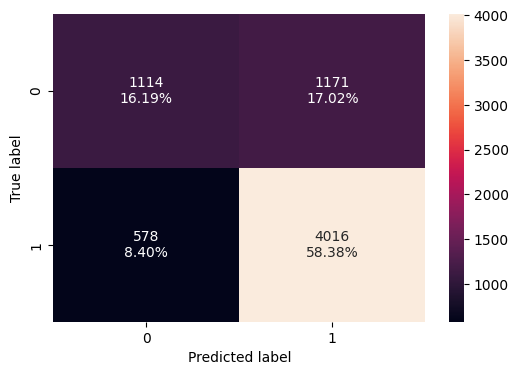

In [ ]:
import numpy as np
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

scorer = 'f1'

print("\n--- Hyperparameter Tuning for RandomForestClassifier using RandomizedSearchCV ---")

# defining model
model = RandomForestClassifier(random_state=1)

# Parameter grid to pass in RandomizedSearchCV
param_grid_rf = {
    "n_estimators": np.arange(50, 151, 25),
    "min_samples_leaf": [1, 2, 4, 5, 10],
    "max_features": ['sqrt', 'log2', None, 0.3, 0.5, 0.7],
    "max_samples": [0.6, 0.7, 0.8, 0.9, 1.0],
}

#Calling RandomizedSearchCV
randomized_cv_rf = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid_rf,
    n_iter=50, # Number of parameter settings that are sampled
    n_jobs=-2, # Use all available CPU cores except one
    scoring=scorer,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=1),
    random_state=1,
    verbose=1 # To see progress
)

#Fitting parameters in RandomizedSearchCV
print("\nFitting RandomizedSearchCV for Random Forest on original training data...")
randomized_cv_rf.fit(X_train, y_train)

# Get the best model
best_rf_model = randomized_cv_rf.best_estimator_

print("\nBest parameters for Random Forest:", randomized_cv_rf.best_params_)
print("Best F1-score (CV on training data):", randomized_cv_rf.best_score_)

# --- Evaluate the Best Random Forest Model on the Validation Set ---

print("\n--- Model Performance on Validation Set (Tuned Random Forest) ---")
rf_val_perf = model_performance_classification_sklearn(best_rf_model, X_val, y_val)
print(rf_val_perf)

# --- STORE RESULTS FOR TUNED RANDOM FOREST ---
all_model_results.append({
    "Model": "Random Forest",
    "Sampling Strategy": "Original", # Because we tuned it on X_train, y_train
    "Tuning Status": "Tuned",
    "F1-score (Val)": rf_val_perf['F1'].iloc[0],
    "Accuracy (Val)": rf_val_perf['Accuracy'].iloc[0],
    "Recall (Val)": rf_val_perf['Recall'].iloc[0],
    "Precision (Val)": rf_val_perf['Precision'].iloc[0],
    "Best Params": randomized_cv_rf.best_params_,
    "Best CV F1 (Train)": randomized_cv_rf.best_score_
})
# --- END STORE RESULTS ---

print("\nConfusion Matrix for Validation Set (Tuned Random Forest):")
confusion_matrix_sklearn(best_rf_model, X_val, y_val)

print("\nRandom Forest hyperparameter tuning and validation evaluation complete.")



**Best practices for hyperparameter tuning in Gradient Boosting:**

`n_estimators`:

* Start with 100 (default) and increase: 100, 200, 300, 500
* Typically, higher values lead to better performance, but they also increase training time
* Use 200–500 for larger datasets or complex problems
* Monitor validation performance to avoid overfitting, as too many estimators can degrade generalization


`learning_rate`:

* Common values to try: 0.1, 0.05, 0.01, 0.005
* Use lower values (e.g., 0.01 or 0.005) if you are using many estimators (e.g., > 200)
* Higher learning rates (e.g., 0.1) can be used with fewer estimators for faster convergence
* Always balance the learning rate with `n_estimators` to prevent overfitting or underfitting


`subsample`:

* Common values: 0.7, 0.8, 0.9, 1.0
* Use a value between `0.7` and `0.9` for improved generalization by introducing randomness
* `1.0` uses the full dataset for each boosting round, potentially leading to overfitting
* Reducing `subsample` can help reduce overfitting, especially in smaller datasets


`max_features`:

* Common values: `"sqrt"`, `"log2"`, or float (e.g., `0.3`, `0.5`)
* `"sqrt"` (default) works well for classification tasks
* Lower values (e.g., `0.3`) help reduce overfitting by limiting the number of features considered at each split

---


--- Hyperparameter Tuning for GradientBoostingClassifier using RandomizedSearchCV (on Original Data) ---

Fitting RandomizedSearchCV for Gradient Boosting on original training data...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters for Gradient Boosting: {'subsample': 0.9, 'n_estimators': 100, 'max_features': 0.5, 'learning_rate': 0.05}
Best F1-score (CV on training data): 0.8246397259940759

--- Model Performance on Validation Set (Tuned Gradient Boosting) ---
   Accuracy    Recall  Precision        F1
0  0.743858  0.878102   0.770435  0.820753

Confusion Matrix for Validation Set (Tuned Gradient Boosting):

Gradient Boosting hyperparameter tuning and validation evaluation complete.

Gradient Boosting hyperparameter tuning and validation evaluation complete.


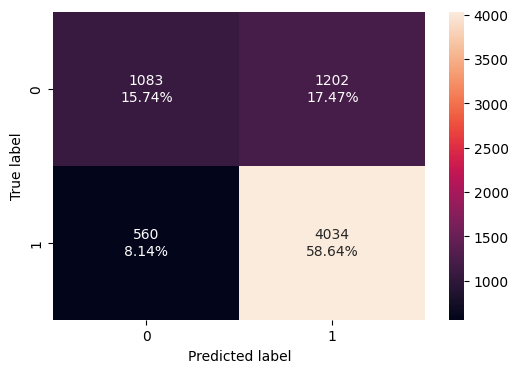

In [ ]:
import numpy as np
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import GradientBoostingClassifier

scorer = 'f1'

print("\n--- Hyperparameter Tuning for GradientBoostingClassifier using RandomizedSearchCV (on Original Data) ---")

# defining model
gbm_model = GradientBoostingClassifier(random_state=1)

# Parameter grid to pass in RandomizedSearchCV
param_grid_gbm = {

    "n_estimators": [100, 200, 300, 500],


    "learning_rate": [0.1, 0.05, 0.01, 0.005],


    "subsample": [0.7, 0.8, 0.9, 1.0],


    "max_features": ['sqrt', 'log2', None, 0.3, 0.5], # None uses all features
}

#Calling RandomizedSearchCV
randomized_cv_gbm = RandomizedSearchCV( # Renamed variable for clarity
    estimator=gbm_model,
    param_distributions=param_grid_gbm,
    n_iter=50, # Number of parameter settings that are sampled (can adjust based on runtime)
    n_jobs=-2, # Use all available CPU cores except one
    scoring=scorer,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=1), # Using 5 splits for CV
    random_state=1,
    verbose=1 # To see progress
)

#Fitting parameters in RandomizedSearchCV
print("\nFitting RandomizedSearchCV for Gradient Boosting on original training data...")
randomized_cv_gbm.fit(X_train, y_train)

# Get the best model
best_gbm_model = randomized_cv_gbm.best_estimator_

print("\nBest parameters for Gradient Boosting:", randomized_cv_gbm.best_params_)
print("Best F1-score (CV on training data):", randomized_cv_gbm.best_score_)

# --- Evaluate the Best GBM Model on the Validation Set ---

print("\n--- Model Performance on Validation Set (Tuned Gradient Boosting) ---")
gbm_val_perf = model_performance_classification_sklearn(best_gbm_model, X_val, y_val)
print(gbm_val_perf)

# --- STORE RESULTS FOR TUNED GBM ---
all_model_results.append({
    "Model": "GBM",
    "Sampling Strategy": "Original", # Because we tuned it on X_train, y_train
    "Tuning Status": "Tuned",
    "F1-score (Val)": gbm_val_perf['F1'].iloc[0],
    "Accuracy (Val)": gbm_val_perf['Accuracy'].iloc[0],
    "Recall (Val)": gbm_val_perf['Recall'].iloc[0],
    "Precision (Val)": gbm_val_perf['Precision'].iloc[0],
    "Best Params": randomized_cv_gbm.best_params_,
    "Best CV F1 (Train)": randomized_cv_gbm.best_score_
})
# --- END STORE RESULTS ---

print("\nConfusion Matrix for Validation Set (Tuned Gradient Boosting):")
confusion_matrix_sklearn(best_gbm_model, X_val, y_val)

print("\nGradient Boosting hyperparameter tuning and validation evaluation complete.")


print("\nGradient Boosting hyperparameter tuning and validation evaluation complete.")


**Best practices for hyperparameter tuning in XGBoost:**

`n_estimators`:

* Start with 50 and increase in steps: 50,75,100,125.
* Use more estimators (e.g., 150-250) when using lower learning rates
* Monitor validation performance
* High values improve learning but increase training time

`subsample`:

* Common values: 0.5, 0.7, 0.8, 1.0
* Use `0.7–0.9` to introduce randomness and reduce overfitting
* `1.0` uses the full dataset in each boosting round; may overfit on small datasets
* Values < 0.5 are rarely useful unless dataset is very large

`gamma`:

* Try values: 0 (default), 1, 3, 5, 8
* Controls minimum loss reduction needed for a split
* Higher values make the algorithm more conservative (i.e., fewer splits)
* Use values > 0 to regularize and reduce overfitting, especially on noisy data


`colsample_bytree`:

* Try values: 0.3, 0.5, 0.7, 1.0
* Fraction of features sampled per tree
* Lower values (e.g., 0.3 or 0.5) increase randomness and improve generalization
* Use `1.0` when you want all features considered for every tree


`colsample_bylevel`:

* Try values: 0.3, 0.5, 0.7, 1.0
* Fraction of features sampled at each tree level (i.e., per split depth)
* Lower values help in regularization and reducing overfitting
* Often used in combination with `colsample_bytree` for fine control over feature sampling

---


--- Hyperparameter Tuning for XGBoostClassifier using RandomizedSearchCV (on Original Data) ---

Fitting RandomizedSearchCV for XGBoost on original training data...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters for XGBoost: {'subsample': 1.0, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 3, 'colsample_bytree': 1.0, 'colsample_bylevel': 0.7}
Best F1-score (CV on training data): 0.825189859476178

--- Model Performance on Validation Set (Tuned XGBoost) ---
   Accuracy    Recall  Precision        F1
0  0.745021  0.869395   0.775835  0.819955

Confusion Matrix for Validation Set (Tuned XGBoost):

XGBoost hyperparameter tuning and validation evaluation complete.


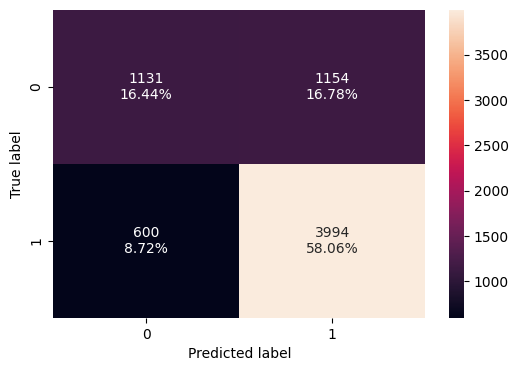

In [ ]:
import numpy as np
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from xgboost import XGBClassifier

scorer = 'f1'

print("\n--- Hyperparameter Tuning for XGBoostClassifier using RandomizedSearchCV (on Original Data) ---")

# defining model
xgb_model = XGBClassifier(random_state=1, eval_metric="logloss", use_label_encoder=False)

# Parameter grid to pass in RandomizedSearchCV
param_grid_xgb = {
    # n_estimators: Start with 50 and increase in steps: 50,75,100,125.

    "n_estimators": [50, 75, 100, 125, 150, 200, 250], # Extended range based on practices

    # learning_rate:
    "learning_rate": [0.1, 0.05, 0.01, 0.005],

    # max_depth:
    "max_depth": [3, 4, 5, 6, 7],

    # subsample: Common values: 0.5, 0.7, 0.8, 1.0
    "subsample": [0.5, 0.7, 0.8, 1.0],

    # colsample_bytree: Try values: 0.3, 0.5, 0.7, 1.0
    "colsample_bytree": [0.3, 0.5, 0.7, 1.0],

    # colsample_bylevel: Try values: 0.3, 0.5, 0.7, 1.0
    "colsample_bylevel": [0.3, 0.5, 0.7, 1.0],

    # gamma: Try values: 0 (default), 1, 3, 5, 8
    "gamma": [0, 1, 3, 5, 8],
}

#Calling RandomizedSearchCV
randomized_cv_xgb = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid_xgb,
    n_iter=50, # Number of parameter settings that are sampled (adjust if too slow)
    n_jobs=-2, # Use all available CPU cores except one
    scoring=scorer,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=1), # Using 5 splits for CV
    random_state=1,
    verbose=1
)

#Fitting parameters in RandomizedSearchCV
print("\nFitting RandomizedSearchCV for XGBoost on original training data...")
randomized_cv_xgb.fit(X_train, y_train)

# Get the best model
best_xgb_model = randomized_cv_xgb.best_estimator_

print("\nBest parameters for XGBoost:", randomized_cv_xgb.best_params_)
print("Best F1-score (CV on training data):", randomized_cv_xgb.best_score_)

# --- Evaluate the Best XGBoost Model on the Validation Set ---

print("\n--- Model Performance on Validation Set (Tuned XGBoost) ---")
xgb_val_perf = model_performance_classification_sklearn(best_xgb_model, X_val, y_val)
print(xgb_val_perf)

# --- STORE RESULTS FOR TUNED XGBOOST ---
all_model_results.append({
    "Model": "XGBoost",
    "Sampling Strategy": "Original", # Because we tuned it on X_train, y_train
    "Tuning Status": "Tuned",
    "F1-score (Val)": xgb_val_perf['F1'].iloc[0],
    "Accuracy (Val)": xgb_val_perf['Accuracy'].iloc[0],
    "Recall (Val)": xgb_val_perf['Recall'].iloc[0],
    "Precision (Val)": xgb_val_perf['Precision'].iloc[0],
    "Best Params": randomized_cv_xgb.best_params_,
    "Best CV F1 (Train)": randomized_cv_xgb.best_score_
})
# --- END STORE RESULTS ---

print("\nConfusion Matrix for Validation Set (Tuned XGBoost):")
confusion_matrix_sklearn(best_xgb_model, X_val, y_val)

print("\nXGBoost hyperparameter tuning and validation evaluation complete.")



## Model Performance Summary and Final Model Selection

In [ ]:
# --- Display Final Summary Table ---
final_summary_df = pd.DataFrame(all_model_results)

# Sort for easier comparison
final_summary_df = final_summary_df.sort_values(
    by=["F1-score (Val)", "Model"], # Sorting by F1-score and then Model name
    ascending=[False, True]
).reset_index(drop=True)

print("\n--- Comprehensive Tuned Model Performance Summary ---")
print(final_summary_df.to_string())


--- Comprehensive Tuned Model Performance Summary ---
           Model Sampling Strategy Tuning Status  F1-score (Val)  Accuracy (Val)  Recall (Val)  Precision (Val)                                                                                                                                   Best Params  Best CV F1 (Train)
0  Random Forest          Original         Tuned        0.821184        0.745748      0.874184         0.774243                                                     {'n_estimators': 100, 'min_samples_leaf': 10, 'max_samples': 0.7, 'max_features': 'sqrt'}            0.824928
1            GBM          Original         Tuned        0.820753        0.743858      0.878102         0.770435                                                           {'subsample': 0.9, 'n_estimators': 100, 'max_features': 0.5, 'learning_rate': 0.05}            0.824640
2        XGBoost          Original         Tuned        0.819955        0.745021      0.869395         0.775835  {'subsampl



**Top Performer (F1-score): Random Forest**

The Tuned Random Forest model, trained on Original Data, achieved the highest F1-score on the validation set: 0.821184. This is marginally higher than GBM and XGBoost.
It also has a very high Recall (0.874) for the 'Certified' class, meaning it's excellent at identifying the applications that will be certified. Its Precision (0.774) is also solid.

It achieved the best balance of Precision and Recall for the "Certified" class on the validation set



## Actionable Insights and Recommendations


# Actionable Insights

*   Wage is Paramount (prevailing_wage): This is consistently the most dominant factor.

    **Insight:** The proposed wage for the foreign worker, relative to the prevailing wage for that occupation and location, is the single most critical determinant.

    **Recommendation:** EasyVisa should strongly advise employers to ensure their proposed wages meet or exceed the prevailing wage. This could be a primary checklist item or a "red flag" indicator.

*   Employer Characteristics are Key (no_of_employees, yr_of_estab): The size of the employer (no_of_employees) and how long they've been established (yr_of_estab) are highly influential.

    **Insight:** More established and potentially larger companies might have a higher success rate, possibly due to more robust compliance processes, demonstrated need, or stability.

    **Recommendation:** EasyVisa can help newer or smaller companies understand these implicit factors and potentially guide them on how to present their case more strongly, or focus on highlighting their specific need for foreign talent.


# Recommendations
*   **Tiered Review System:** Implement a system where applications flagged as "Highly Certified" by the model (e.g., above a certain probability threshold) are fast-tracked for expedited review.
*   **Data-Driven Consultation:** Offer a premium service where EasyVisa analyzes a client's application details against the model's identified drivers. This allows them to provide data-backed advice on the likelihood of approval.


